In [10]:
!pip install pandas

In [11]:
import pandas as pd
import sqlite3
from sqlite3 import Error

In [12]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [13]:
query="""
WITH sup_table AS (SELECT DATE(timestamp) AS date, 
CASE WHEN strftime('%w',timestamp) IN ('0', '6') THEN 'weekend' ELSE 'working_day' END AS Day,
strftime('%H',timestamp) AS hour, COUNT(strftime('%H',timestamp)) AS cnt
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY DATE(timestamp), strftime('%H',timestamp))

SELECT Day, hour, AVG(cnt)
FROM sup_table
GROUP BY Day, hour
"""

df = pd.read_sql(query, connection)

weekend = df[df["Day"] == "weekend"]
working_day = df[df["Day"] == "working_day"]

In [14]:
weekend = weekend[["hour", "AVG(cnt)"]]
working_day = working_day[["hour", "AVG(cnt)"]]

weekend = weekend.rename(columns={'AVG(cnt)': 'weekend'})
working_day = working_day.rename(columns={'AVG(cnt)': 'working_day'})

In [15]:
weekday_n_weekend = pd.merge(weekend, working_day, how="left", on="hour")
weekday_n_weekend["hour"] = weekday_n_weekend["hour"].astype(int)

all_hours = pd.DataFrame({'hour' : range(24)})
weekday_n_weekend = all_hours.merge(weekday_n_weekend, how='left', on="hour").fillna(0)

In [16]:
weekday_n_weekend

,hour,weekend,working_day
0,0,2.000000,3.000000
1,1,6.000000,0.000000
2,2,0.000000,0.000000
3,3,1.000000,2.000000
4,4,0.000000,0.000000
5,5,2.000000,7.500000
6,6,0.000000,0.000000
7,7,4.000000,5.166667
8,8,7.000000,3.700000
9,9,3.666667,6.000000


array([<Axes: title={'center': 'weekend'}, xlabel='hour'>,
       <Axes: title={'center': 'working_day'}, xlabel='hour'>],
      dtype=object)

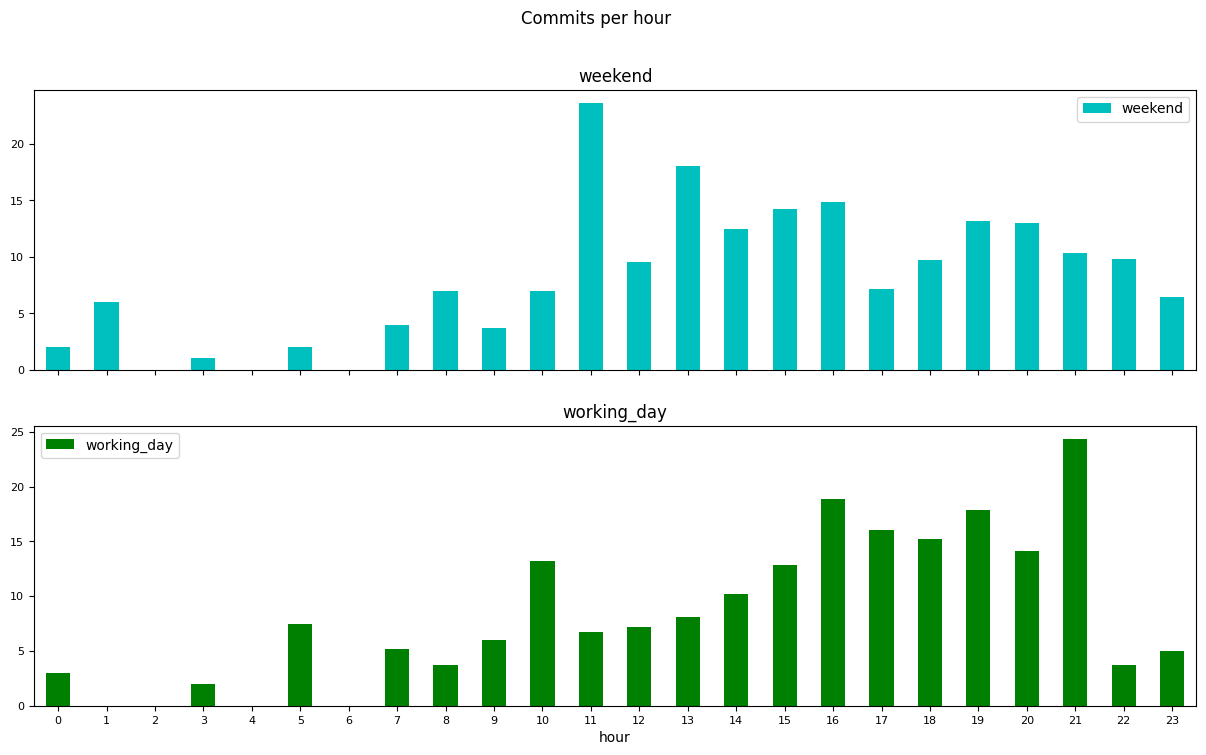

In [17]:
weekday_n_weekend.plot.bar(x = "hour", fontsize=8, figsize=(15, 8), subplots=True, rot=0, title="Commits per hour", color=["c", "g"])

#### Is the dynamic different on working days and weekends? Yes
* The hour when the largest number of commits during working days = 21
* The hour when the largest number of commits during weekend = 11

In [18]:
connection.close()